<a href="https://colab.research.google.com/github/AaryanGotad/S.I.L.C./blob/main/model_training/SILC_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S.I.L.C. - Satellite Image Land Classification System

Importing required modules

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
import helper_functions as hf

--2026-04-22 10:05:36--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-04-22 10:05:36 (116 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense, Rescaling, RandomFlip, RandomRotation, RandomZoom, InputLayer, Input, RandomTranslation, RandomContrast, RandomBrightness
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import History
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from tensorflow.random import set_seed
from tensorflow.keras.callbacks import ModelCheckpoint

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import shutil
import random
from tqdm import tqdm
import itertools
from sklearn.metrics import confusion_matrix

# import helper_functions as hf

## Data Exploration

### Data Loading `(EuroSAT)`

In [ ]:
# loading train, test and validation csv files, containing filenames of all images in the respective sets
train_df = pd.read_csv('/content/drive/MyDrive/EuroSAT/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/EuroSAT/test.csv')
val_df = pd.read_csv('/content/drive/MyDrive/EuroSAT/validation.csv')
len(train_df), len(test_df), len(val_df)

(18900, 2700, 5400)

In [ ]:
train_df.head()

,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [ ]:
# loading classname mappings from provided json file
with open('/content/drive/MyDrive/EuroSAT/label_map.json') as f:
  label_map = json.load(f)

labels = list(label_map.keys())
labels

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [ ]:
# creating full dataset df (train+val)
full_train_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
len(full_train_df)

24300

### Helper Functions

In [ ]:
# creating a method to create target folders of each set and move images there

def copy_images(parent_folder, new_folder, dataset, target_labels):
  """
  Copies 'label_map['class_name']' images in the dataset from the 'parent_folder'
  to the 'target folder'.

  E.g. move Forest images to EuroSAT/forest_subset/train, EuroSAT/forest_subset/test &
  EuroSAT/forest_subset/validation folders.

  Parameters
  --------
  parent_folder (str) - original folder path with all data
  new_folder (str) - new folder to copy the images to
  dataset (pd DataFrame) - dataframe with filenames and labels
  target_labels (list) - list of target labels to copy e.g. ["Forest", "Highway"]
  """
  # getting filenames from dataset to a list
  filepaths = dataset['Filename'].to_list()

  # Creating new folders to copy the images to
  for i in target_labels:
    # Making target_directory (parent_folder/new_folder/target_label[i])
    os.makedirs(parent_folder + '/' + new_folder + '/' + i,
               exist_ok=True)

    # comment out below code if not copying full dataset (train+val)
    # os.makedirs(new_folder + '/' + i,
    #            exist_ok=True)

  images_moved = [] # keeping track of imaged moved
  for index, j in enumerate(filepaths):
    # Creaing orignal image path and new path
    og_path = os.path.join(parent_folder, j)
    new_path = os.path.join(parent_folder, new_folder, j)

    # Copy image from old path to new path
    shutil.copy(og_path, new_path)
    images_moved.append(new_path)

    if (index != 0) and (index % 500 == 0):
        print(f"Progress: {index}/{len(filepaths)} images copied to '{parent_folder + '/' + new_folder}' succefully...")

In [ ]:
# This function walks through a directory and returns the number of files in each (images in our case)
def walk(path):
  """
  Walks through path and lists number of files in each directory.

  Parameters
  --------
  path (str) - path to walk through
  """
  files = 0
  # Walking through the train directory and listing the number of files
  for dirpath, dirnames, filenames in os.walk(path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in'{dirpath}'")
    files += len(filenames)

  print(f"Total images: {files}.")

In [ ]:
def get_percent_images(target_dir, new_dir, sample_amount=0.1, random_state=42):
    """
    Get sample_amount percentage of random images from target_dir and copy them to new_dir.

    Preserves subdirectory file names.

    E.g. target_dir=pizza_steak/train/steak/all_files
                -> new_dir_name/train/steak/X_percent_of_all_files

    Parameters
    --------
    target_dir (str) - file path of directory you want to extract images from
    new_dir (str) - new directory path you want to copy original images to
    sample_amount (float), default 0.1 - percentage of images to copy (e.g. 0.1 = 10%)
    random_state (int), default 42 - random seed value
    """
    # Set random seed for reproducibility
    random.seed(random_state)

    # Get a list of dictionaries of image files in target_dir
    # e.g. [{"class_name":["2348348.jpg", "2829119.jpg"]}]
    images = [{dir_name: os.listdir(target_dir + dir_name)} for dir_name in os.listdir(target_dir)]

    for i in images:
        for k, v in i.items():
            # How many images to sample?
            sample_number = round(int(len(v)*sample_amount))
            print(f"There are {len(v)} total images in '{target_dir+k}' so we're going to copy {sample_number} to the new directory.")
            print(f"Getting {sample_number} random images for {k}...")
            random_images = random.sample(v, sample_number)

            # Make new dir for each key
            new_target_dir = new_dir + k
            print(f"Making dir: {new_target_dir}")
            os.makedirs(new_target_dir, exist_ok=True)

            # Keep track of images moved
            images_moved = []

            # Create file paths for original images and new file target
            print(f"Copying images from: {target_dir}\n\t\t to: {new_target_dir}/\n")
            for file_name in tqdm(random_images):
                og_path = target_dir + k + "/" + file_name
                new_path = new_target_dir + "/" + file_name

                # Copy images from OG path to new path
                shutil.copy2(og_path, new_path)
                images_moved.append(new_path)

            # Make sure number of images moved is correct
            assert len(os.listdir(new_target_dir)) == sample_number
            assert len(images_moved) == sample_number

In [ ]:
# function to get random sample of images
def get_percent_images_not_using(target_dir, new_dir, sample_amount=0.1, random_state=42):
  """
  Get sample_amount percentage of random images from target_dir and copy them to new_dir.

  Preserves subdirectory filenames.

  E.g. target_dir=content/drive/MyDrive/EuroSAT/train/Forest
              -> new_dir=content/drive/MyDrive/EuroSAT/train_sample_percent

  Parameters
  --------
  target_dir (str) - file path of directory you want to extract images from
  new_dir (str) - new directory path you want to copy original images to
  sample_amount (float), default 0.1 - percentage of images to copy (e.g. 0.1 = 10%)
  random_state (int), default 42 - random seed value
  """
  # Set random seed for reproducibility
  random.seed(random_state)

  # Getting a list of dictionaries of image files in target_dir
  # e.g. [["Forestimage01.jpg", "Forestimage02.jpg"],
  #         ["Urbanimage01.jpg", "Urbanimage02.jpg"], ...]
  images = [os.listdir(target_dir + '/' + dir_name) for dir_name in os.listdir(target_dir)]

  all_selected_files = [] # to store the shuffled filenames
  num_imgs = 0 # to keep track of number of images moved

  # shuffling files listwise
  for file_list in images:
    sample_number = round(int(len(file_list) * sample_amount))
    num_imgs += sample_number
    # sample and add to the master list
    sampled = random.sample(file_list, sample_number)
    all_selected_files.extend(sampled)

  # shuffling the combined list
  random.shuffle(all_selected_files)

  # keep track of images moved
  images_moved = []

  # copying the shuffled files to new directory
  for index, file_name in enumerate(tqdm(all_selected_files)):
    og_path = os.path.join(target_dir, f'{file_name.partition('_')[0]}', file_name)
    new_path = os.path.join(new_dir, file_name)

    shutil.copy(og_path, new_path)
    images_moved.append(new_path)

    if index != 0 and index % 500 == 0:
      print(f"Progress: {index}/{len(all_selected_files)} images copied to '{new_dir}' succefully...")

  # making sure number of images moved is correct
  assert len(os.listdir(new_dir)) == num_imgs
  assert len(images_moved) == num_imgs
  print(f"Total umber of images moved: {num_imgs}")

In [ ]:
# let's visualize our images
def view_random_image(target_dir, target_class):
  """
  Returns a random image, selected from the target directory, of the target class.

  Parameters:
    target_dir (str) - target directory to sample images from
    target_class (str) - target class to filter the images by

  Returns:
    img (numpy array) - sampled random image
  """

  # setup the target directory (we'll view images from here)
  target_folder = target_dir + target_class

  # get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # read-in the image and plot it using matplotlib
  filename = target_folder + '/' + random_image[0]
  img = mpimg.imread(filename)
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img, filename

In [ ]:
# Function to plot the training and validation curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics

  Parameters:
    history (history object) - TensorFlow model training history object, containing all
                                training logs

  Output:
    Two plots of training and validation loss and accuracy curves
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss'])) # how many epochs did we run for

  # plotting loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.legend()

  # plotting accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()

In [ ]:
# function to combine multiple training metrics of same model, into one history object variable
def combine_history(history_list):
  """
  This function combines multiple Keras history objects into one true history object.

  Parameters:
    history_list (list) - list of history objects to combine

  Returns:
    combined_history (history object) - combined history object
  """
  # a new keras history object
  combined_history = History()
  combined_history.history = {}

  # extracting and merging the metrics data
  for key in history_list[0].history.keys():
    combined_history.history[key] = []

    for history in history_list:
      combined_history.history[key].extend(history.history[key])

  # inheriting parameters and model preferences from the last run
  combined_history.set_model(history_list[-1].model)
  combined_history.params = history_list[-1].params

  # Updating the total epochs count in params
  first_metric_key = list(combined_history.history.keys())[0]
  combined_history.params['epochs'] = len(combined_history.history[first_metric_key])

  return combined_history

In [ ]:
def compare_history(original_history, new_history, initial_epochs=5):
  """
  Compares two model history objects.
  """
  # get original history measurements.
  acc = original_history.history['accuracy']
  loss = original_history.history['loss']

  print(len(acc))

  val_acc = original_history.history['val_accuracy']
  val_loss = original_history.history['val_loss']

  # Combining original history with new history
  total_acc = acc + new_history.history['accuracy']
  total_loss = loss + new_history.history['loss']

  total_val_acc = val_acc + new_history.history['val_accuracy']
  total_val_loss = val_loss + new_history.history['val_loss']

  print(len(total_acc))
  print(total_acc)

  # making plots
  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(total_acc, label='Training Accuracy')
  plt.plot(total_val_acc, label='Validation Accuracy')
  plt.plot([initial_epochs-1, initial_epochs-1],
           plt.ylim(), label="Start Fine Tuning") # reshift plot around epochs
  plt.legend(loc='lower right')
  plt.title("Training and Validation Accuracy")

  plt.subplot(2, 1, 2)
  plt.plot(total_loss, label="training Loss")
  plt.plot(total_val_loss, label="Validation Loss")
  plt.plot([initial_epochs-1, initial_epochs-1],
           plt.ylim(), label="Start Fine Tuning") # reshift plot around epochs
  plt.legend(loc='upper right')
  plt.title("Training and Validation Loss")
  plt.xlabel("epoch")
  plt.show()

### Organising data in train, test, and val sets (One time process)

In [ ]:
# creating a training set
copy_images('/content/drive/MyDrive/EuroSAT', 'train', train_df, list(label_map.keys()))

Streaming output truncated to the last 5000 lines.
18897            AnnualCrop  
18898           Residential  
18899         PermanentCrop  

[18900 rows x 4 columns] dataset  Industrial succesfully...
Copied 18716 images from        Unnamed: 0                                           Filename  Label  \
0           16257                      AnnualCrop/AnnualCrop_142.jpg      0   
1            3297  HerbaceousVegetation/HerbaceousVegetation_2835...      2   
2           17881               PermanentCrop/PermanentCrop_1073.jpg      6   
3            2223                      Industrial/Industrial_453.jpg      4   
4            4887  HerbaceousVegetation/HerbaceousVegetation_1810...      2   
...           ...                                                ...    ...   
18895        4498  HerbaceousVegetation/HerbaceousVegetation_1952...      2   
18896        1149                           Pasture/Pasture_1252.jpg      5   
18897       15489                     AnnualCrop/AnnualCrop_23

In [ ]:
walk('/content/drive/MyDrive/EuroSAT/train')

There are 10 directories and 0 images in'/content/drive/MyDrive/EuroSAT/train'
There are 0 directories and 2100 images in'/content/drive/MyDrive/EuroSAT/train/AnnualCrop'
There are 0 directories and 2100 images in'/content/drive/MyDrive/EuroSAT/train/Forest'
There are 0 directories and 2100 images in'/content/drive/MyDrive/EuroSAT/train/HerbaceousVegetation'
There are 0 directories and 1750 images in'/content/drive/MyDrive/EuroSAT/train/Highway'
There are 0 directories and 1750 images in'/content/drive/MyDrive/EuroSAT/train/Industrial'
There are 0 directories and 1400 images in'/content/drive/MyDrive/EuroSAT/train/Pasture'
There are 0 directories and 1750 images in'/content/drive/MyDrive/EuroSAT/train/PermanentCrop'
There are 0 directories and 2100 images in'/content/drive/MyDrive/EuroSAT/train/Residential'
There are 0 directories and 1750 images in'/content/drive/MyDrive/EuroSAT/train/River'
There are 0 directories and 2100 images in'/content/drive/MyDrive/EuroSAT/train/SeaLake'
Total

In [ ]:
# Now making the validation set
copy_images('/content/drive/MyDrive/EuroSAT', 'validation', val_df, list(label_map.keys()))

KeyboardInterrupt: 

In [ ]:
# Making sure all images are copied
walk('/content/drive/MyDrive/EuroSAT/validation')

There are 10 directories and 0 images in'/content/drive/MyDrive/EuroSAT/validation'
There are 0 directories and 600 images in'/content/drive/MyDrive/EuroSAT/validation/AnnualCrop'
There are 0 directories and 600 images in'/content/drive/MyDrive/EuroSAT/validation/Forest'
There are 0 directories and 600 images in'/content/drive/MyDrive/EuroSAT/validation/HerbaceousVegetation'
There are 0 directories and 500 images in'/content/drive/MyDrive/EuroSAT/validation/Highway'
There are 0 directories and 500 images in'/content/drive/MyDrive/EuroSAT/validation/Industrial'
There are 0 directories and 400 images in'/content/drive/MyDrive/EuroSAT/validation/Pasture'
There are 0 directories and 500 images in'/content/drive/MyDrive/EuroSAT/validation/PermanentCrop'
There are 0 directories and 600 images in'/content/drive/MyDrive/EuroSAT/validation/Residential'
There are 0 directories and 500 images in'/content/drive/MyDrive/EuroSAT/validation/River'
There are 0 directories and 600 images in'/content/dr

In [ ]:
# copying test set images
copy_images('/content/drive/MyDrive/EuroSAT', 'test', test_df, list(label_map.keys()))

Progress: 500/2700 images copied to '/content/drive/MyDrive/EuroSAT/test' succefully...
Progress: 1000/2700 images copied to '/content/drive/MyDrive/EuroSAT/test' succefully...
Progress: 1500/2700 images copied to '/content/drive/MyDrive/EuroSAT/test' succefully...
Progress: 2000/2700 images copied to '/content/drive/MyDrive/EuroSAT/test' succefully...
Progress: 2500/2700 images copied to '/content/drive/MyDrive/EuroSAT/test' succefully...


In [ ]:
walk('/content/drive/MyDrive/EuroSAT/test')

There are 10 directories and 0 images in'/content/drive/MyDrive/EuroSAT/test'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/AnnualCrop'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/Forest'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/HerbaceousVegetation'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/Highway'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/Industrial'
There are 0 directories and 200 images in'/content/drive/MyDrive/EuroSAT/test/Pasture'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/PermanentCrop'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/Residential'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/River'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/SeaLake'
Total images: 2700.


In [ ]:
# Copying full training dataset (train+val)
copy_images(parent_folder='/content/drive/MyDrive/EuroSAT',
            new_folder='full_train',
            dataset=full_train_df,
            target_labels=labels)

Progress: 500/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 1000/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 1500/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 2000/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 2500/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 3000/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 3500/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 4000/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 4500/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 5000/24300 images copied to '/content/drive/MyDrive/EuroSAT/full_train' succefully...
Progress: 5500/24300 images copied to '/c

### Loading data and saved models from gdrive to local env.

In [ ]:
# copying the tran, test, val files in a zip file to local env for faster training
!cp /content/drive/MyDrive/EuroSAT/eurosat.zip /content/
print('Copied eurosat.zip successfully!')

#unzipping the file
!unzip -q /content/eurosat.zip -d /content/eurosat
print("Unzipped the zip file succesfully! Happy training!")

Copied eurosat.zip successfully!
Unzipped the zip file succesfully! Happy training!


In [ ]:
# copying the tran, test, val files in a zip file to local env for faster training
!cp /content/drive/MyDrive/EuroSAT/full_train.zip /content/
print('Copied full_train.zip successfully!')

#unzipping the file
!unzip -q /content/full_train.zip -d /content/eurosat/
print("Unzipped the zip file succesfully! Happy training!")

Copied full_train.zip successfully!
Unzipped the zip file succesfully! Happy training!


In [ ]:
# copying models from gdrive to local env
!cp /content/drive/MyDrive/EuroSAT/models/efficientnet_model.keras /content/
print('Copied efficientnet_model succesfully!')

!cp /content/drive/MyDrive/EuroSAT/models/efficientnet_model_full_train.keras /content/
print('Copied efficientnet_model_full_train succesfuly!')

Copied efficientnet_model succesfully!
Copied efficientnet_model_full_train succesfuly!


In [ ]:
# copying fine-tuned models from gdrive to local env
# !cp /content/drive/MyDrive/EuroSAT/models/efficientnet_fine_10_layers_model.keras /content/
# print('Copied efficientnet_fine_10_layers_model succesfully!')

# !cp /content/drive/MyDrive/EuroSAT/models/efficientnet_fine_10_layers_model_full_train.keras /content/
# print('Copied efficientnet_fine_10_layers_model_full_train succesfully!')

!cp /content/drive/MyDrive/EuroSAT/models/best_efficientnet_fine_10_layers_model_full_train.keras /content/
print('Copied best_efficientnet_fine_10_layers_model_full_train succesfully!')

Copied best_efficientnet_fine_10_layers_model_full_train succesfully!


### Inspecting the data (becoming one with it)

In [ ]:
!ls /content/drive/MyDrive/EuroSAT/train

AnnualCrop  HerbaceousVegetation  Industrial  PermanentCrop  River
Forest	    Highway		  Pasture     Residential    SeaLake


Image shape: (64, 64, 3)


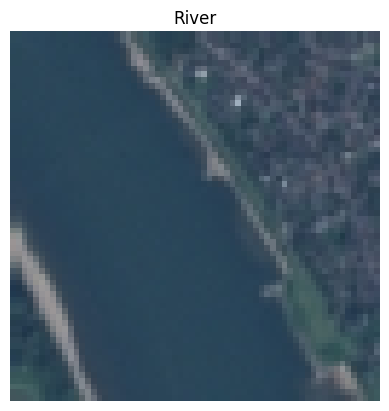

In [ ]:
# viewing a random image from the training dataset
img, filename = view_random_image(target_dir='drive/MyDrive/EuroSAT/train/',
                                  target_class='River')

In [ ]:
filename

'drive/MyDrive/EuroSAT/train/River/River_552.jpg'

### Preparing data for training

In [ ]:
import tensorflow as tf

# setting random seed
tf.random.set_seed(42)

# preprocessing data (normalizing all of the pixel values) (legacy code)
# train_datagen = ImageDataGenerator(rescale=1/255.)
# val_datagen = ImageDataGenerator(rescale=1/255.)
# test_datagen = ImageDataGenerator(rescale=1/255.)

# setup paths to our directories
train_dir = '/content/eurosat/train'
val_dir = 'eurosat/validation'
test_dir = 'eurosat/test'
full_train_dir = 'eurosat/full_train'

# import data from directories and turn it into batches
train_data = tf.keras.utils.image_dataset_from_directory(
    directory=train_dir,
    batch_size=64,
    image_size=(64, 64),
    label_mode='categorical',
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    directory=val_dir,
    batch_size=64,
    image_size=(64, 64),
    label_mode='categorical',
    seed=42
)

test_data = tf.keras.utils.image_dataset_from_directory(
    directory=test_dir,
    batch_size=64,
    image_size=(64, 64),
    label_mode='categorical',
    shuffle=False, # only for making the confusion matrix
    seed=42
)

# full_train_data = image_dataset_from_directory(
#     directory=full_train_dir,
#     batch_size=64,
#     image_size=(64, 64),
#     label_mode='categorical',
#     seed=42
# )

# Optimization for better training speed
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
# full_train_data = full_train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

Found 18900 files belonging to 10 classes.
Found 5400 files belonging to 10 classes.
Found 2700 files belonging to 10 classes.


# Model Training

### Data Augmentation model

In [ ]:
# Creating a dedicated augmentation model
data_augmentation = Sequential([
    RandomFlip('horizontal_and_vertical'), # for top down satellite images this is great
    RandomRotation(0.2),                   # Rotate between -72 and +72 degrees
    RandomZoom(0.2),                        # Skight zoom to handle differnt altitudes
    RandomTranslation(height_factor=0.1, width_factor=0.1),

    # colour and light related augmentation
    RandomContrast(0.2),
    RandomBrightness(0.2),
    tf.keras.layers.GaussianNoise(0.1)
], name='data_augmentation')

Original image shape: (64, 64, 3)
Augmented image shape: (1, 64, 64, 3)


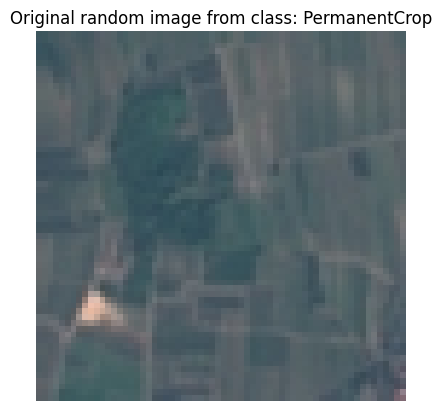

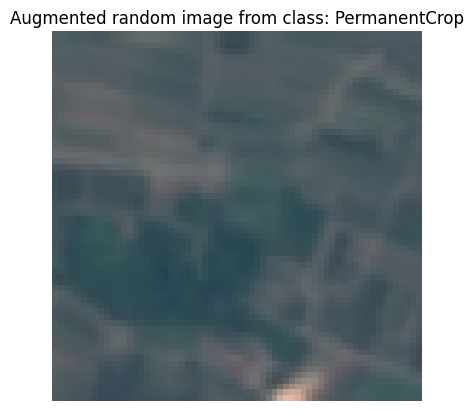

In [ ]:
# viewing a random image
target_class = random.choice(labels) # choosing a random class
target_dir = train_dir + '/' + target_class # creating the target directory

random_image = random.choice(os.listdir(target_dir)) # choosing a random image from the target directory
random_image_path = target_dir + '/' + random_image # creating the choosen random image path

img = mpimg.imread(random_image_path) # reading in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False) # turning off the axes

# augmenting the image
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3)

plt.figure()
plt.imshow(tf.squeeze(augmented_img) / 255.) # requires normalization after augmentation
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False)

print(f"Original image shape: {img.shape}")
print(f"Augmented image shape: {augmented_img.shape}")

### Checkpoint Callback

In [ ]:
checkpoint_path = 'ten_percent_model_checkpoints_weights/checkpoint.weights.h5'

# creating a model checkpoint callback that save's the model's weights only
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_path,
                                      save_weights_only=True, # set to False to save the entire model
                                      save_best_only=True, # save only the best model weights instead of a model every epoch
                                      save_freq='epoch', # save every epoch
                                      verbose=1)

### Baseline Custom CNN

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# setting random seed
tf.random.set_seed(42)

# Creating baseline model
cnn_baseline_model = Sequential([
    # Input shape & Rescaling
    InputLayer(input_shape=(224, 224, 3)), # Changed from (64, 64, 3) to (224, 224, 3)
    Rescaling(1./255),

    # data augmentation (only active during training)
    data_augmentation,

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(),

    GlobalAveragePooling2D(),

    Dense(10, activation='softmax')
])

# compiling model
cnn_baseline_model.compile(loss='categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

# fitting the model
cnn_baseline_history = cnn_baseline_model.fit(train_data,
                                              epochs=5,
                                              validation_data=val_data)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


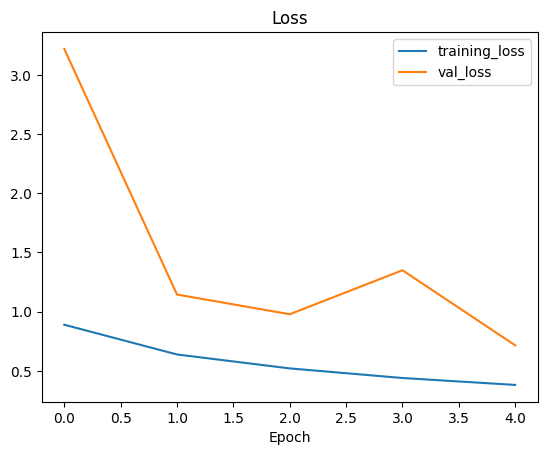

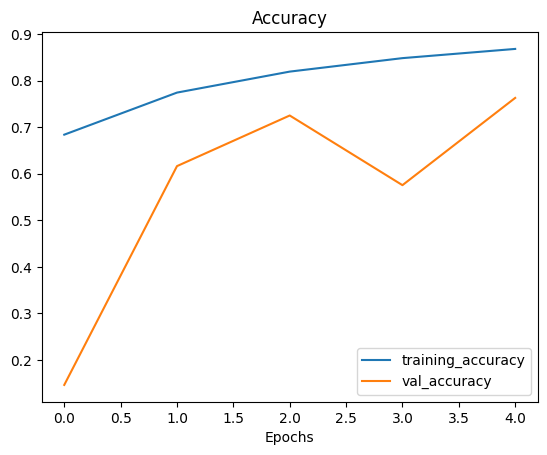

In [ ]:
# plotting training data to see how well the training went
plot_loss_curves(cnn_baseline_history)

Hmm... So, the model results are good for a baseline model.

Model is training well, but showing some classic signs of **overfitting**, as there is some gap between training metrics and validation metrics.

The model is not generalizing well yet.

I will train this model for additional 5 epochs (continue training, not from scratch), so the total epochs would be 10.and

Then analyze whether by the end the model is overfitting further, or not.

I am not going to spend much time tuning this CNN, as I will shift to tranfer learning next, which will solve the generalization issues.

In [ ]:
# additional 5 epochs training
cnn_baseline_history_add = cnn_baseline_model.fit(train_data,
                                                  epochs=5,
                                                  validation_data=val_data)

Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8837 - loss: 0.3360 - val_accuracy: 0.7526 - val_loss: 0.7362
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8906 - loss: 0.3136 - val_accuracy: 0.6650 - val_loss: 1.2399
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8985 - loss: 0.2911 - val_accuracy: 0.7828 - val_loss: 0.6486
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9081 - loss: 0.2694 - val_accuracy: 0.7765 - val_loss: 0.6271
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9118 - loss: 0.2556 - val_accuracy: 0.7533 - val_loss: 0.7700


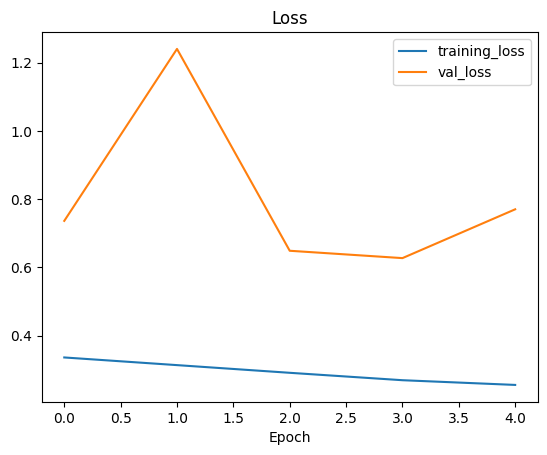

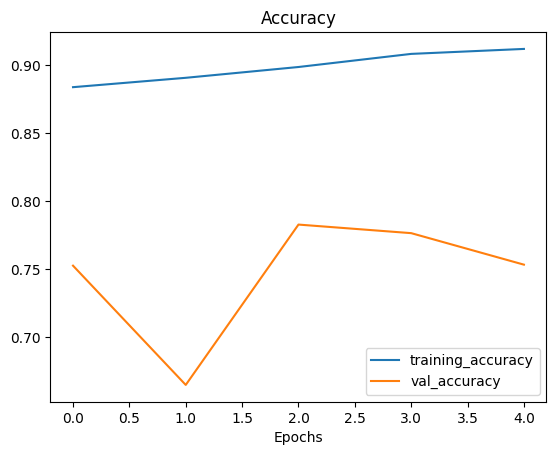

In [ ]:
# plotting these training stats
plot_loss_curves(cnn_baseline_history_add)

List of history objects created succesfully.
Combined training stats acquired. Will plot them now!


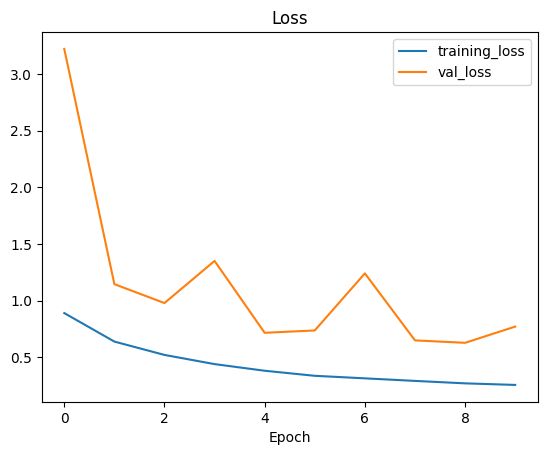

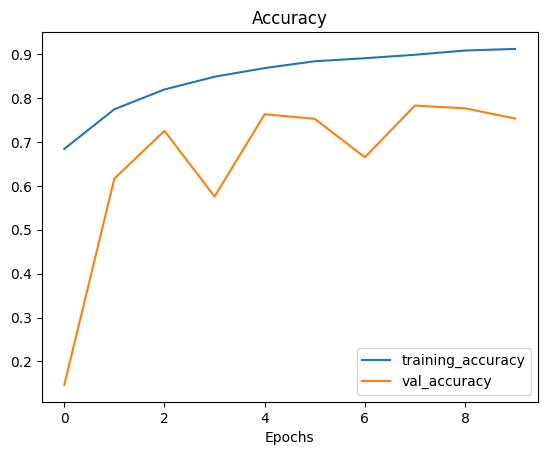

In [ ]:
# now seeing the stats of combined 10 epochs run
# making a list of the two history objects
history_list = [cnn_baseline_history, cnn_baseline_history_add]
print("List of history objects created succesfully.")

# passing this list to my custom helper function
combined_history = combine_history(history_list)
print("Combined training stats acquired. Will plot them now!")

# plotting this new combined history
plot_loss_curves(combined_history)

The baseline is clearly overfitting now. Given the high training metrics but rather stagnant validation metrics. Good, it has done its job. Now I will do an upgrade in the next session, "Transfer Learning (Feature Extraction)" This will help fix the generalization problem.

### Tiny VGG Architecture (A learning experiment)

In [ ]:
# setting random seed
set_seed(42)

# creating model
tiny_vgg = Sequential([
    InputLayer(input_shape=(64, 64, 3)),
    Rescaling(1./255),

    data_augmentation,

    Conv2D(10, kernel_size=3, padding='same', activation='relu'),

    Conv2D(10, 3, padding='same', activation='relu'),
    MaxPool2D(),

    Conv2D(10, 3, padding='same', activation='relu'),

    Conv2D(10, 3, padding='same', activation='relu'),
    MaxPool2D(),

    tf.keras.layers.Flatten(),
    Dense(10, activation='softmax')
])

# compiling model
tiny_vgg.compile(loss='categorical_crossentropy',
                 optimizer='adam',
                 metrics=['accuracy'])

# fitting the model for 5 epochs
history_tiny_vgg = tiny_vgg.fit(train_data,
                                epochs=5,
                                validation_data=val_data,
                                validation_steps=int(0.25 * len(val_data)),
                                callbacks=[hf.create_tensorboard_callback('tensorboard', 'tiny_vgg_experiment')])

Saving TensorBoard log files to: tensorboard/tiny_vgg_experiment/20260421-102726
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


296/296 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.1096 - loss: 2.3057 - val_accuracy: 0.0952 - val_loss: 2.2946
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1134 - loss: 2.2964 - val_accuracy: 0.0179 - val_loss: 2.2961
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1115 - loss: 2.2957 - val_accuracy: 0.1228 - val_loss: 2.2924
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1100 - loss: 2.2957 - val_accuracy: 0.1153 - val_loss: 2.2918
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1080 - loss: 2.2953 - val_accuracy: 0.1243 - val_loss: 2.2943


### Tranfer Learning (Feature Extraction)

Starting with EfficientNetB0, add my custom head to it, freeze its layers

In [ ]:
# defining input shape explicitly
Inputs = Input(shape=(64, 64, 3), name='input_layer')

# applying the preprocess input function as a lamda layer
# x = preprocess_input(Inputs)

# base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
base_model.trainable = False

# building head
# x = data_augmentation(Inputs)
x = base_model(Inputs, training=False)

x = GlobalAveragePooling2D(name='gap_layer')(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax', name='output_layer')(x)

# creating model from functional API
efficientnet_model = Model(inputs=Inputs, outputs=outputs)

# compiling model
efficientnet_model.compile(loss='categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

initial_epochs = 5

# fitting the model
efficientnet_history = efficientnet_model.fit(train_data,
                                              epochs=initial_epochs,
                                              validation_data=val_data,
                                              validation_steps=len(val_data),
                                              callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_feature_extraction'),
                                                         checkpoint_callback])

Saving TensorBoard log files to: tensorboard/efficientnet_feature_extraction/20260421-111826
Epoch 1/5
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7068 - loss: 0.9837
Epoch 1: val_loss improved from None to 0.31459, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 1: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 54s 103ms/step - accuracy: 0.7989 - loss: 0.6482 - val_accuracy: 0.9019 - val_loss: 0.3146
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8775 - loss: 0.3669
Epoch 2: val_loss improved from 0.31459 to 0.25940, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 2: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8768 - loss: 0.3661 - val_accuracy: 0.9157 - val_loss: 0.2594
Epoch 3/5
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - 

In [ ]:
efficientnet_history_2 = efficientnet_model.fit(train_data,
                                                epochs=5,
                                                validation_data=val_data,
                                                validation_steps=int(0.25 * len(val_data)))

Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9260 - loss: 0.2132 - val_accuracy: 0.9226 - val_loss: 0.2540
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9310 - loss: 0.1985 - val_accuracy: 0.9152 - val_loss: 0.2763
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9332 - loss: 0.1907 - val_accuracy: 0.9204 - val_loss: 0.2601
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9396 - loss: 0.1767 - val_accuracy: 0.9219 - val_loss: 0.2468
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9401 - loss: 0.1715 - val_accuracy: 0.9249 - val_loss: 0.2631


Woah those are some scores!

Now let's visualize the training metrics.

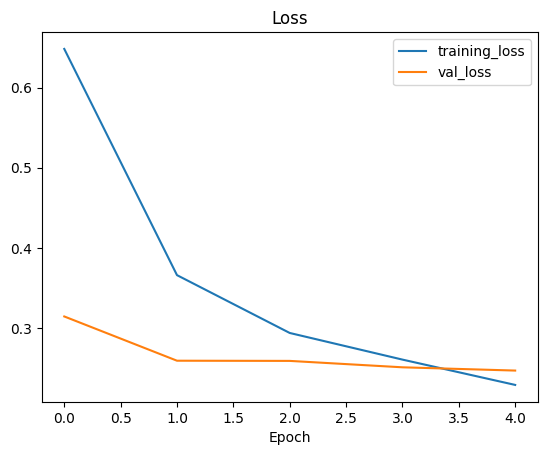

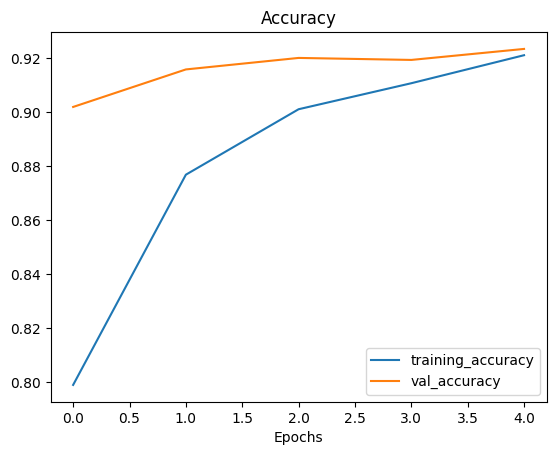

In [ ]:
# plotting training metrics
plot_loss_curves(efficientnet_history)

The model is generalizing so much better than my custom CNN!

Validation metrics were low to begin with,

but the training metrics did catchup towards the end of the 5 epochs run.

Let's save this model.

After this i will train this model on full training data (train set + val set), and save that aswell

In [ ]:
# saving model
efficientnet_model.save('efficientnet_model.keras')

In [ ]:
# lets load the model and evaluate it to confirm the model saved correctly
loaded_model = tf.keras.models.load_model('efficientnet_model.keras')
loaded_model.evaluate(val_data)

85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.9230 - loss: 0.2438


[0.2437746673822403, 0.9229629635810852]

In [ ]:
efficientnet_model.load_weights(checkpoint_path)
loaded_weights_model_results = efficientnet_model.evaluate(val_data)
loaded_weights_model_results

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9233 - loss: 0.2471


[0.24710707366466522, 0.9233333468437195]

In [ ]:
# comparing this with our existing model
efficientnet_model.evaluate(val_data)

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9230 - loss: 0.2438


[0.24377472698688507, 0.9229629635810852]

Ok, now let's train this model on full training data.

In [ ]:
# defining input shape explicitly
Inputs = Input(shape=(64, 64, 3))

# applying the preprocess input function as a lamda layer
# x = preprocess_input(Inputs)

# base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
base_model.trainable = False

# building head
x = base_model(Inputs)

x = GlobalAveragePooling2D(name='gap_layer')(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax', name='output_layer')(x)

# creating model from functional API
efficientnet_model_full = Model(inputs=Inputs, outputs=outputs)

# compiling model
efficientnet_model_full.compile(loss='categorical_crossentropy',
                                optimizer='adam',
                                metrics=['accuracy'])

# fitting the model
efficientnet_history_full = efficientnet_model_full.fit(full_train_data,
                                                        epochs=5,
                                                        validation_data=test_data,
                                                        callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_feature_extraction_full'),
                                                                   checkpoint_callback])

Saving TensorBoard log files to: tensorboard/efficientnet_feature_extraction_full/20260422-064858
Epoch 1/5
376/380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7287 - loss: 0.8944
Epoch 1: val_loss improved from None to 0.26191, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 1: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
380/380 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.8155 - loss: 0.5975 - val_accuracy: 0.9085 - val_loss: 0.2619
Epoch 2/5
379/380 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8887 - loss: 0.3481
Epoch 2: val_loss improved from 0.26191 to 0.22580, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 2: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8862 - loss: 0.3496 - val_accuracy: 0.9230 - val_loss: 0.2258
Epoch 3/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

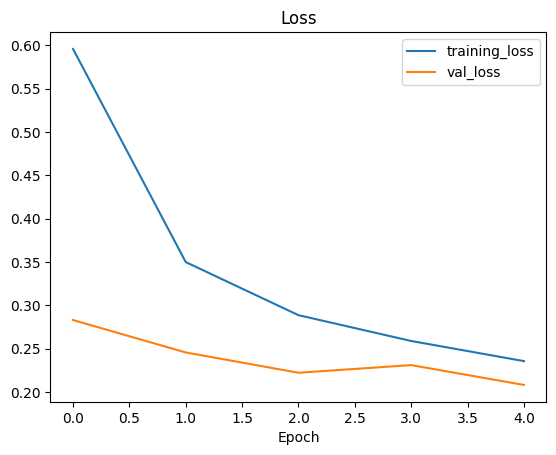

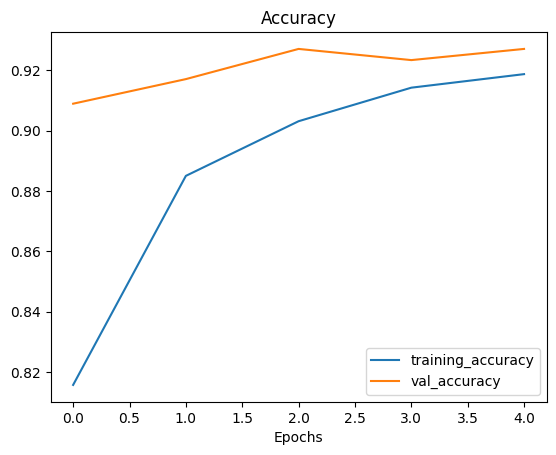

In [ ]:
# plotting training metrics
plot_loss_curves(efficientnet_history_full)

Ok the model is definetly generalising very well compared to my baseline custom CNN.

I will save this model aswell now.

Then will return next time to do fine-tuning.

In [ ]:
# saving model
efficientnet_model_full.save('efficientnet_model_full_train.keras')

In [ ]:
# checking model summary
efficientnet_model_full.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_layer                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,555,587 (17.38 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 335,638 (1.28 MB)

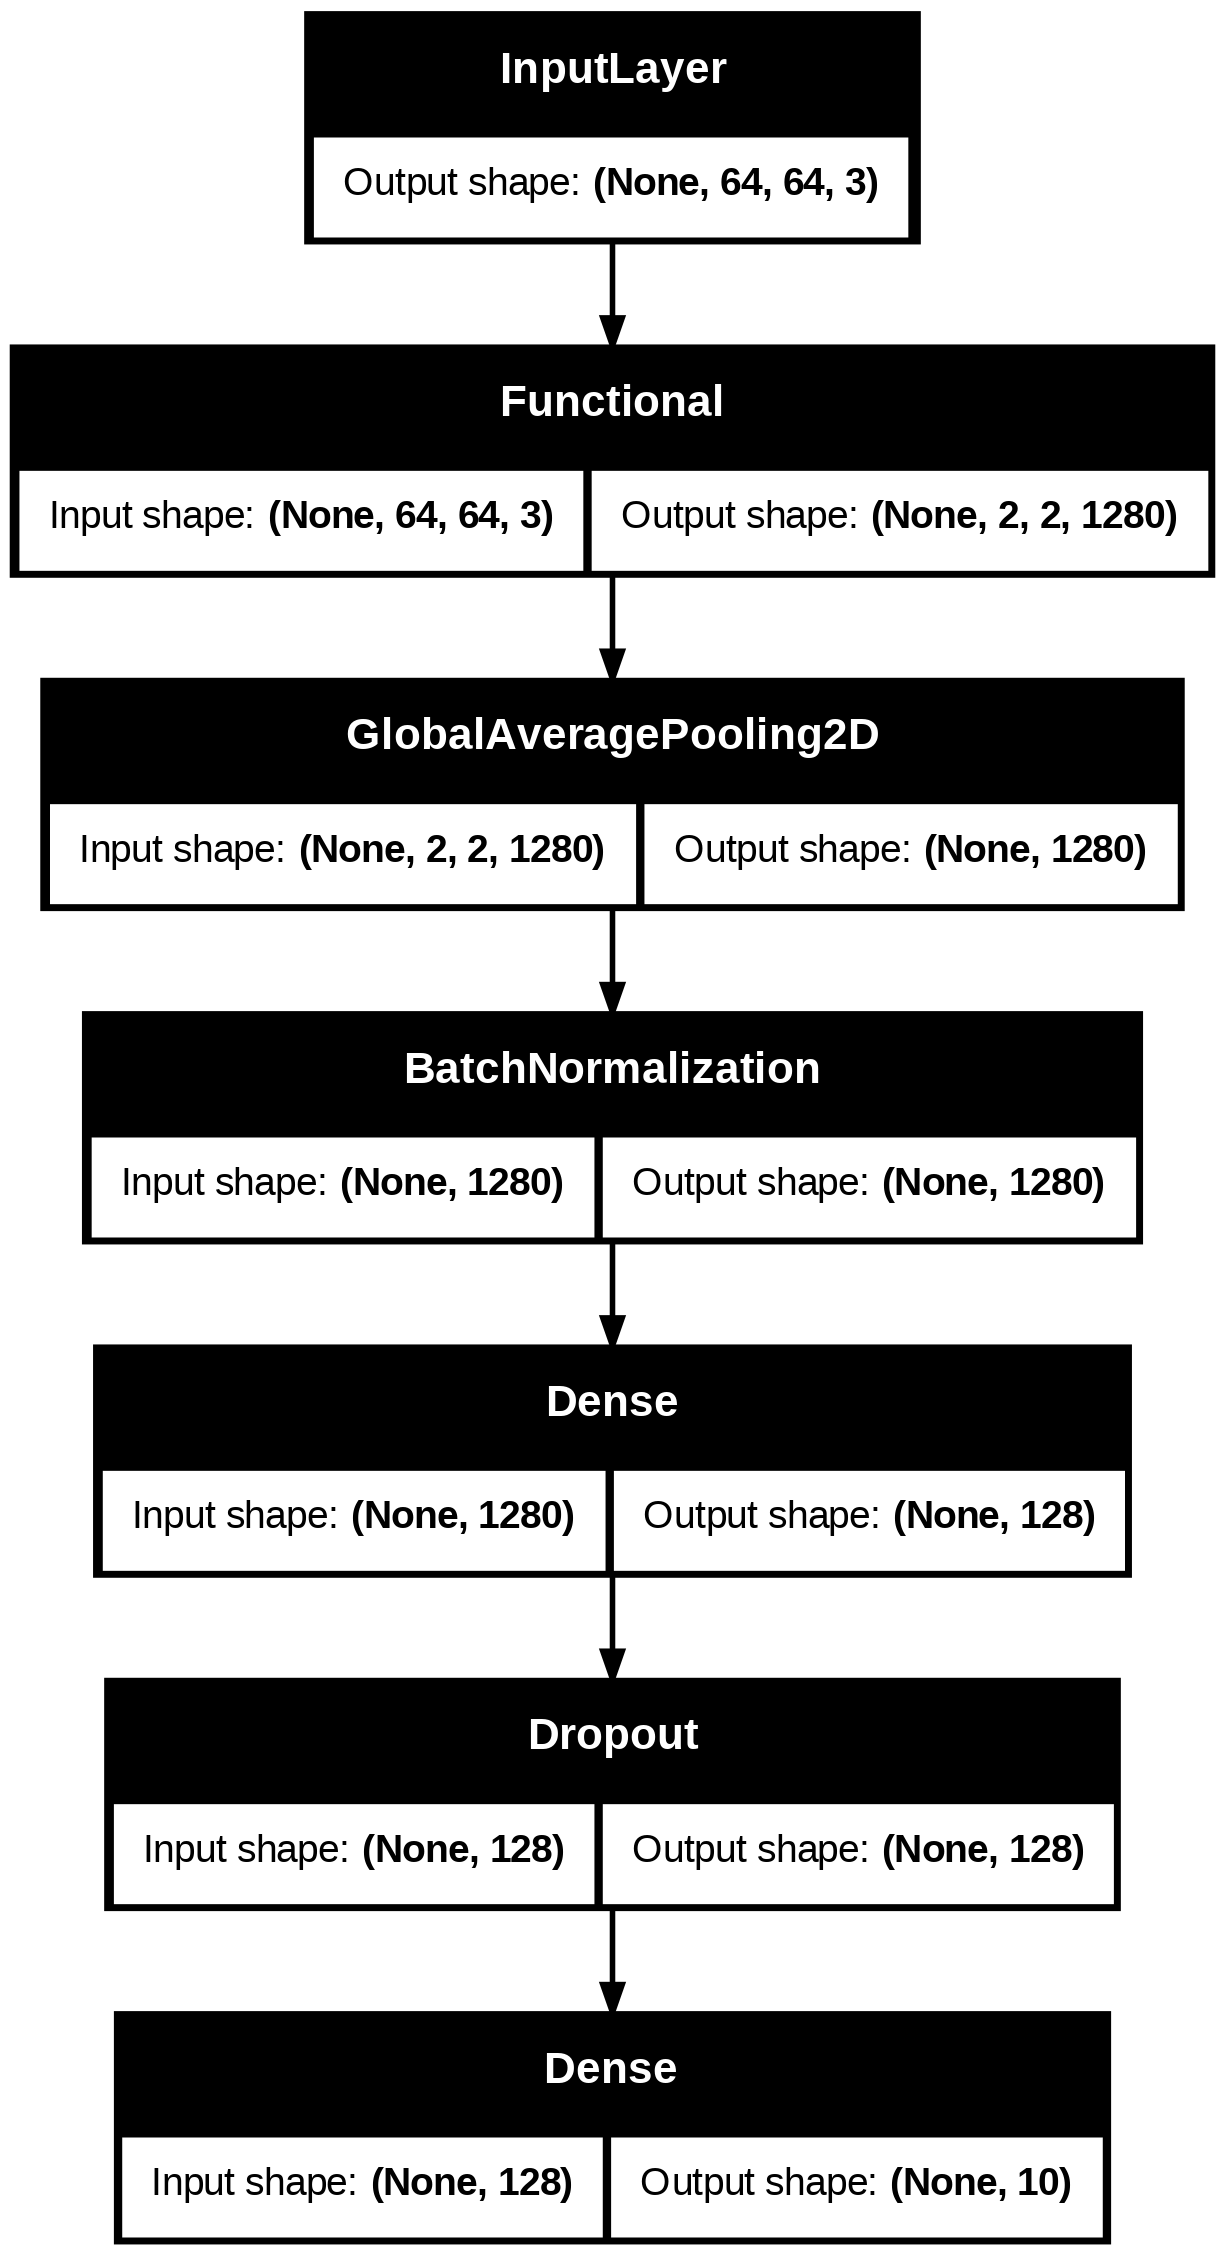

In [ ]:
# plotting our model
plot_model(efficientnet_model_full, show_shapes=True)

Task's for next session:
* try tiny vgg architecture
* try training efficientnet with input size 224x224
* explore the idea of featureing multiple models on the final app

### Transfer Learning: Fine Tuning

In [ ]:
efficientnet_base_model = efficientnet_model.layers[1]

# layers which are tuneable
print(efficientnet_base_model.name)
print(len(efficientnet_base_model.trainable_variables))

efficientnetb0
0


In [ ]:
# check which layers are tunebale (trainable)
for layer_number, layer in enumerate(efficientnet_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 False
1 rescaling_7 False
2 normalization_3 False
3 rescaling_8 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

unfreezing top 10 layers of the base model

In [ ]:
efficientnet_base_model.trainable = True

# freezing all layers except for the last 10
for layer in efficientnet_base_model.layers[:-10]:
  layer.trainable = False

# recompiling the whole model
efficientnet_model.compile(loss='categorical_crossentropy',
                           optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # 10x lower learning rate for fine tuning
                           metrics=['accuracy'])

In [ ]:
# checking which layers are tuneable
for layer_number, layer in enumerate(efficientnet_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 False
1 rescaling_7 False
2 normalization_3 False
3 rescaling_8 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [ ]:
print(len(efficientnet_model.trainable_variables))

16


In [ ]:
fine_tune_epochs = initial_epochs + 5

efficientnet_history_fine = efficientnet_model.fit(train_data,
                                                   epochs=fine_tune_epochs,
                                                   validation_data=val_data,
                                                   initial_epoch=efficientnet_history.epoch[-1],
                                                   validation_steps=len(val_data),
                                                   callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning/20260421-113550
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.9002 - loss: 0.2991 - val_accuracy: 0.9222 - val_loss: 0.2459
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9308 - loss: 0.2017 - val_accuracy: 0.9272 - val_loss: 0.2318
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9438 - loss: 0.1714 - val_accuracy: 0.9313 - val_loss: 0.2281
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9487 - loss: 0.1506 - val_accuracy: 0.9328 - val_loss: 0.2189
Epoch 9/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9565 - loss: 0.1279 - val_accuracy: 0.9356 - val_loss: 0.2186
Epoch 10/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9612 - loss: 0.1143 - val_accuracy: 0.9389 - val_loss: 0.2140


5
11
[0.7989417910575867, 0.8767724633216858, 0.9010052680969238, 0.9106349349021912, 0.9210053086280823, 0.900158703327179, 0.9307936429977417, 0.943756639957428, 0.9486772418022156, 0.9564550518989563, 0.961216926574707]


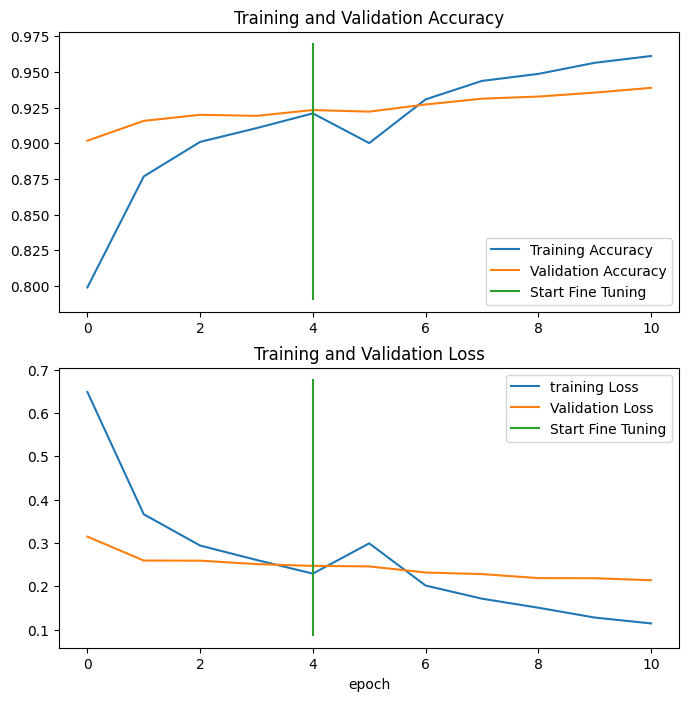

In [ ]:
compare_history(original_history=efficientnet_history,
                new_history=efficientnet_history_fine,
                initial_epochs=5)

In [ ]:
efficientnet_model.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 282ms/step - accuracy: 0.9407 - loss: 0.1842


[0.18422962725162506, 0.9407407641410828]

Saving model

In [ ]:
efficientnet_model.save('efficientnet_fine_10_layers_model.keras')
print("Model saved!")

Model saved!


In [ ]:
efficientnet_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_layer                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,342,051 (24.19 MB)

 Trainable params: 1,061,050 (4.05 MB)

 Non-trainable params: 3,158,899 (12.05 MB)

 Optimizer params: 2,122,102 (8.10 MB)

Training on full dataset

In [ ]:
efficientnet_full_base_model = efficientnet_model_full.layers[1]
efficientnet_full_base_model.name

'efficientnetb0'

In [ ]:
# layers which are tuneable
print(efficientnet_full_base_model.name)
print(len(efficientnet_full_base_model.trainable_variables))

efficientnetb0
0


In [ ]:
# check which layers are tunebale (trainable)
for layer_number, layer in enumerate(efficientnet_full_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_5 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [ ]:
efficientnet_full_base_model.trainable = True

# freezing all layers except for the last 10
for layer in efficientnet_full_base_model.layers[:-10]:
  layer.trainable = False

# recompiling the whole model
efficientnet_model_full.compile(loss='categorical_crossentropy',
                                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # 10x lower learning rate for fine tuning
                                metrics=['accuracy'])

In [ ]:
# check which layers are tunebale (trainable)
for layer_number, layer in enumerate(efficientnet_full_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_5 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [ ]:
print(len(efficientnet_model_full.trainable_variables))

16


In [ ]:
initial_epochs = 5
fine_tune_epochs = initial_epochs + 5

efficientnet_history_fine_full = efficientnet_model_full.fit(full_train_data,
                                                             epochs=fine_tune_epochs,
                                                             validation_data=test_data,
                                                             initial_epoch=efficientnet_history_full.epoch[-1],
                                                             validation_steps=len(test_data),
                                                             callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning_full')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning_full/20260422-065213
Epoch 5/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9674 - loss: 0.0971 - val_accuracy: 0.9448 - val_loss: 0.1781
Epoch 6/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9703 - loss: 0.0896 - val_accuracy: 0.9448 - val_loss: 0.1791
Epoch 7/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9728 - loss: 0.0825 - val_accuracy: 0.9430 - val_loss: 0.1857
Epoch 8/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9772 - loss: 0.0703 - val_accuracy: 0.9493 - val_loss: 0.1740
Epoch 9/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9770 - loss: 0.0673 - val_accuracy: 0.9474 - val_loss: 0.1796
Epoch 10/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9785 - loss: 0.0646 - val_accuracy: 0.9511 - val_loss: 0.1740


5
11
[0.8180658221244812, 0.8897119164466858, 0.90390944480896, 0.9138683080673218, 0.9233333468437195, 0.9613227248191833, 0.9667195677757263, 0.9713756442070007, 0.9730687737464905, 0.9774603247642517, 0.9774603247642517]


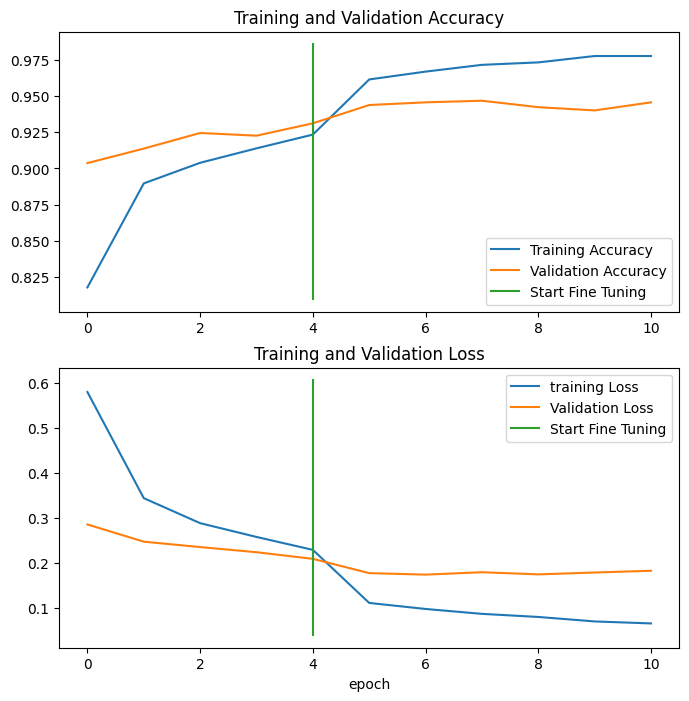

In [ ]:
compare_history(original_history=efficientnet_history_full,
                new_history=efficientnet_history_fine_full,
                initial_epochs=5)

In [ ]:
efficientnet_model_full.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9511 - loss: 0.1740


[0.17398858070373535, 0.9511111378669739]

saving model (full training data)

In [ ]:
efficientnet_model_full.save('efficientnet_fine_10_layers_model_full_train.keras')
print("Model saved!")

Model saved!


In [ ]:
efficientnet_model_full.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_layer                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,342,051 (24.19 MB)

 Trainable params: 1,061,050 (4.05 MB)

 Non-trainable params: 3,158,899 (12.05 MB)

 Optimizer params: 2,122,102 (8.10 MB)

unfreezing 10 more layers

In [ ]:
# loading model
effnet_fine_20_layers = tf.keras.models.load_model('efficientnet_fine_10_layers_model.keras')
print(len(effnet_fine_20_layers.trainable_variables))

16


In [ ]:
# evaluating model to makesure model is correctly loaded
effnet_fine_20_layers.evaluate(val_data)

85/85 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.9389 - loss: 0.2140


[0.21397748589515686, 0.9388889074325562]

In [ ]:
effnet_fine_20_layers_base_model = effnet_fine_20_layers.layers[1]

# how many layers are currently trainable
for layer_number, layer in enumerate(effnet_fine_20_layers_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 True
1 rescaling_7 False
2 normalization_3 False
3 rescaling_8 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze

In [ ]:
effnet_fine_20_layers_base_model = effnet_fine_20_layers.layers[1]

# Set all layers in the base model to non-trainable initially to reset their states
for layer in effnet_fine_20_layers_base_model.layers:
    layer.trainable = False

# Now, unfreeze the last 20 layers
for layer in effnet_fine_20_layers_base_model.layers[-20:]:
    layer.trainable = True

# recompiling the model
effnet_fine_20_layers.compile(loss='categorical_crossentropy',
                              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # 10x slower than previous fine tune attempt
                              metrics=['accuracy'])

In [ ]:
# making sure correct number of layers are unfrozen
for layer_number, layer in enumerate(effnet_fine_20_layers_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 False
1 rescaling_7 False
2 normalization_3 False
3 rescaling_8 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [ ]:
print(len(effnet_fine_20_layers.trainable_variables))

25


In [ ]:
initial_epochs = 10
fine_tune_epochs = initial_epochs + 5

efficientnet_history_fine_full = effnet_fine_20_layers.fit(train_data,
                                                           epochs=fine_tune_epochs,
                                                           validation_data=val_data,
                                                           initial_epoch=initial_epochs-1,
                                                           validation_steps=len(val_data),
                                                           callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning_20_layers')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning_20_layers/20260422-063225
Epoch 10/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - accuracy: 0.8648 - loss: 0.4181 - val_accuracy: 0.9028 - val_loss: 0.3189
Epoch 11/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8844 - loss: 0.3410 - val_accuracy: 0.9004 - val_loss: 0.3303
Epoch 12/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9010 - loss: 0.2933 - val_accuracy: 0.9035 - val_loss: 0.3174
Epoch 13/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9101 - loss: 0.2678 - val_accuracy: 0.9093 - val_loss: 0.3055
Epoch 14/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9168 - loss: 0.2483 - val_accuracy: 0.9120 - val_loss: 0.2963
Epoch 15/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9222 - loss: 0.2309 - val_accuracy: 0.9157 - val_loss: 0.2892


In [ ]:
effnet_fine_20_layers.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 310ms/step - accuracy: 0.9196 - loss: 0.2568


[0.2568499445915222, 0.9196296334266663]

Trying on full training data

In [ ]:
# loading the full trained model
effnet_fine_20_layers_full_train = tf.keras.models.load_model('efficientnet_fine_10_layers_model_full_train.keras')

print(len(effnet_fine_20_layers_full_train.trainable_variables))

16


In [ ]:
effnet_fine_20_layers_full_train.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.9511 - loss: 0.1740


[0.17398859560489655, 0.9511111378669739]

In [ ]:
effnet_fine_20_layers_full_train_base_model = effnet_fine_20_layers_full_train.layers[1]

# how many layers are currently trainable
for layer_number, layer in enumerate(effnet_fine_20_layers_full_train_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_5 True
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze

In [ ]:
# Set all layers in the base model to non-trainable initially to reset their states
for layer in effnet_fine_20_layers_full_train_base_model.layers:
    layer.trainable = False

# Now, unfreeze the last 20 layers
for layer in effnet_fine_20_layers_full_train_base_model.layers[-20:]:
    layer.trainable = True

# recompiling the model
effnet_fine_20_layers_full_train.compile(loss='categorical_crossentropy',
                              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # 10x slower than previous fine tune attempt
                              metrics=['accuracy'])

In [ ]:
# how many layers are currently trainable
for layer_number, layer in enumerate(effnet_fine_20_layers_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 False
1 rescaling_7 False
2 normalization_3 False
3 rescaling_8 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [ ]:
print(len(effnet_fine_20_layers_full_train.trainable_variables))

25


In [ ]:
initial_epochs_prev_run = 5 # This refers to the number of epochs the model was trained for initially
fine_tune_epochs = initial_epochs_prev_run + 5

efficientnet_history_fine_20_full = effnet_fine_20_layers_full_train.fit(full_train_data,
                                                                         epochs=fine_tune_epochs,
                                                                         validation_data=test_data,
                                                                         initial_epoch=initial_epochs_prev_run,
                                                                         validation_steps=len(test_data),
                                                                         callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning_20_layers_full_train')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning_20_layers_full_train/20260422-065607
Epoch 10/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.8829 - loss: 0.3578 - val_accuracy: 0.9152 - val_loss: 0.2849
Epoch 11/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9101 - loss: 0.2821 - val_accuracy: 0.9159 - val_loss: 0.2788
Epoch 12/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9187 - loss: 0.2424 - val_accuracy: 0.9204 - val_loss: 0.2639
Epoch 13/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9263 - loss: 0.2177 - val_accuracy: 0.9230 - val_loss: 0.2504
Epoch 14/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9359 - loss: 0.1930 - val_accuracy: 0.9263 - val_loss: 0.2431
Epoch 15/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9386 - loss: 0.1794 - val_accuracy: 0.9285 - val_loss: 0.2371


Training for a 5 more epochs now as the training is going in the right direction

In [ ]:
initial_epochs_prev_run = 10
fine_tune_epochs = initial_epochs_prev_run + 5

efficientnet_history_fine_20_full_2 = effnet_fine_20_layers_full_train.fit(full_train_data,
                                                                           epochs=fine_tune_epochs,
                                                                           validation_data=test_data,
                                                                           initial_epoch=initial_epochs_prev_run,
                                                                           validation_steps=len(test_data),
                                                                           callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning_20_layers_full_train')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning_20_layers_full_train/20260422-070123
Epoch 11/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9433 - loss: 0.1656 - val_accuracy: 0.9337 - val_loss: 0.2307
Epoch 12/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9454 - loss: 0.1600 - val_accuracy: 0.9348 - val_loss: 0.2243
Epoch 13/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9490 - loss: 0.1473 - val_accuracy: 0.9348 - val_loss: 0.2205
Epoch 14/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9533 - loss: 0.1384 - val_accuracy: 0.9363 - val_loss: 0.2167
Epoch 15/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9547 - loss: 0.1318 - val_accuracy: 0.9381 - val_loss: 0.2135


In [ ]:
initial_epochs_prev_run = 15
fine_tune_epochs = initial_epochs_prev_run + 5

efficientnet_history_fine_20_full_2 = effnet_fine_20_layers_full_train.fit(full_train_data,
                                                                           epochs=fine_tune_epochs,
                                                                           validation_data=test_data,
                                                                           initial_epoch=initial_epochs_prev_run,
                                                                           validation_steps=len(test_data),
                                                                           callbacks=[hf.create_tensorboard_callback('tensorboard', 'efficientnet_fine_tuning_20_layers_full_train')])

Saving TensorBoard log files to: tensorboard/efficientnet_fine_tuning_20_layers_full_train/20260422-070219
Epoch 16/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9578 - loss: 0.1262 - val_accuracy: 0.9381 - val_loss: 0.2104
Epoch 17/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9588 - loss: 0.1220 - val_accuracy: 0.9370 - val_loss: 0.2076
Epoch 18/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9582 - loss: 0.1206 - val_accuracy: 0.9396 - val_loss: 0.2054
Epoch 19/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9630 - loss: 0.1075 - val_accuracy: 0.9433 - val_loss: 0.2032
Epoch 20/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9631 - loss: 0.1042 - val_accuracy: 0.9430 - val_loss: 0.2015


In [ ]:
effnet_fine_20_layers_full_train.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9430 - loss: 0.2015


[0.2015014886856079, 0.9429629445075989]

In [ ]:
efficientnet_model_full.evaluate(test_data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9511 - loss: 0.1740


[0.17398859560489655, 0.9511111378669739]

In [ ]:
efficientnet_model_full.save('best_efficientnet_fine_10_layers_model_full_train.keras')

## Inference Testing

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

Creating a function to preprocess images to load into Model

In [ ]:
def load_and_prep_image(filename, img_shape=64):
  """
  Reads an image from filename, turns it into a tensor and reshapes it
  to (image_shape, image_shape, colour channels).
  """
  # read in the image
  img = tf.io.read_file(filename=filename)

  # decoding the read file into a tensor (force 3 channels for RGB)
  img = tf.image.decode_image(img, channels=3)

  # resizing the image
  img = tf.image.resize_with_pad(img,
                                 img_shape,
                                 img_shape,
                                 method=tf.image.ResizeMethod.BILINEAR,
                                 antialias=True)

  # since i am using efficientnet model from tf.keras.applications
  # the rescale layer is baked in to the model, i don't need any rescalling here

  # converting pixel values to float32
  img = tf.cast(img, tf.float32)

  # Even though efficientnet has built it rescalling
  # adding this to be absolutely sure to match efficientnet's expected input
  img = tf.keras.applications.efficientnet.preprocess_input(img)

  # adding batch dimension ( [1, 64, 64, 3] )
  img = tf.expand_dims(img, axis=0)

  return img

Image shape: (64, 64, 3)


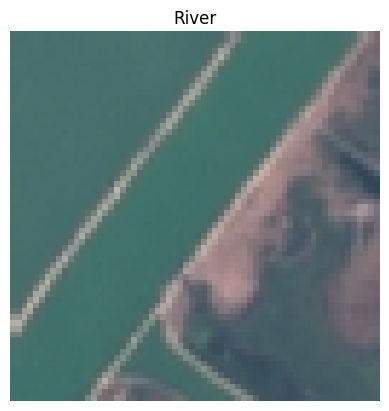

In [ ]:
test_image, filename = view_random_image('/content/drive/MyDrive/EuroSAT/test/',
                                          target_class='River')

In [ ]:
filename

'/content/drive/MyDrive/EuroSAT/test/River/River_1017.jpg'

In [ ]:
prep_test_image = load_and_prep_image(filename=filename)
prep_test_image

<tf.Tensor: shape=(1, 64, 64, 3), dtype=float32, numpy=
array([[[[ 88., 104., 117.],
         [ 86., 104., 116.],
         [ 90., 108., 120.],
         ...,
         [103., 102., 108.],
         [104.,  99., 106.],
         [108., 101., 109.]],

        [[ 88., 102., 113.],
         [ 86., 103., 113.],
         [ 89., 107., 119.],
         ...,
         [102., 103., 108.],
         [101.,  98., 105.],
         [106., 101., 108.]],

        [[ 97., 110., 119.],
         [ 96., 110., 119.],
         [ 89., 103., 114.],
         ...,
         [106., 113., 119.],
         [104., 107., 112.],
         [105., 106., 111.]],

        ...,

        [[ 45.,  74.,  88.],
         [ 45.,  73.,  87.],
         [ 45.,  72.,  89.],
         ...,
         [ 48.,  71.,  89.],
         [ 45.,  71.,  88.],
         [ 46.,  71.,  91.]],

        [[ 46.,  74.,  88.],
         [ 46.,  74.,  88.],
         [ 41.,  68.,  85.],
         ...,
         [ 45.,  71.,  88.],
         [ 45.,  71.,  88.],
         [ 

In [ ]:
# loading model
model = load_model('/content/best_efficientnet_fine_10_layers_model_full_train.keras')
print("Model loaded succesfuly!")

Model loaded succesfuly!


In [ ]:
prediction = model.predict(prep_test_image)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


array([[7.3054826e-12, 7.6408387e-11, 2.3119999e-11, 6.0165719e-05,
        1.5228277e-12, 1.2592545e-10, 2.8878537e-11, 4.3184020e-12,
        9.9993980e-01, 1.1866662e-10]], dtype=float32)

In [ ]:
labels

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [ ]:
pred = labels[tf.argmax(prediction[0])]
pred

'River'

In [ ]:
# 1. Get the probabilities and indices for the top 3
top_k_values, top_k_indices = tf.math.top_k(prediction[0], k=3)

# 2. Convert to numpy for easy printing/looping
probs = top_k_values.numpy()
indices = top_k_indices.numpy()

# 3. Print the results
print("Top 3 Predictions:")
for i in range(3):
    class_name = labels[indices[i]]
    confidence = probs[i] * 100
    print(f"{i+1}: {class_name} ({confidence:.2f}%)")


Top 3 Predictions:
1: River (96.60%)
2: Highway (3.37%)
3: Pasture (0.03%)


In [ ]:
forest = load_and_prep_image('/content/forest_sample.png')
forest

<tf.Tensor: shape=(1, 64, 64, 3), dtype=float32, numpy=
array([[[[14.068637, 23.425917, 18.281761],
         [43.068073, 47.30109 , 20.416868],
         [59.765976, 60.969345, 21.050385],
         ...,
         [14.061584, 21.154177, 16.822134],
         [19.837854, 27.754684, 21.88828 ],
         [ 0.      ,  0.      ,  0.      ]],

        [[19.527258, 27.021496, 16.42165 ],
         [22.699736, 29.145985, 16.117302],
         [38.06455 , 45.274548, 20.873392],
         ...,
         [17.916319, 27.078932, 19.757092],
         [22.680485, 33.35934 , 21.500252],
         [ 0.      ,  0.      ,  0.      ]],

        [[69.86489 , 73.1704  , 20.266905],
         [58.5744  , 63.800186, 19.77469 ],
         [32.79211 , 39.82536 , 19.302652],
         ...,
         [20.016014, 29.764513, 21.281927],
         [15.983909, 24.564714, 18.289907],
         [ 0.      ,  0.      ,  0.      ]],

        ...,

        [[58.6138  , 64.93059 , 23.000801],
         [41.00896 , 49.777004, 22.704905],
  

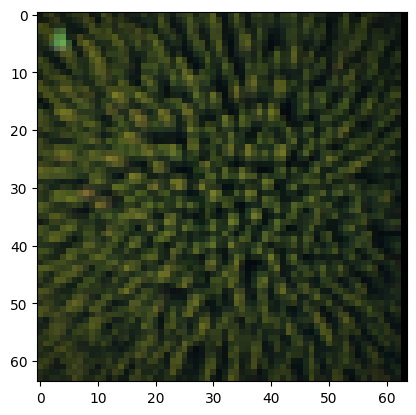

In [ ]:
plt.imshow(forest[0]/255.)

In [ ]:
forest_pred = model.predict(forest)
forest_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[3.5663479e-07, 1.5892361e-05, 7.8375975e-04, 3.4206194e-05,
        4.1358915e-05, 4.2163610e-04, 6.6437030e-07, 2.1175716e-04,
        9.9267805e-01, 5.8123721e-03]], dtype=float32)

In [ ]:
# 1. Get the probabilities and indices for the top 3
top_3_values, top_3_indices = tf.math.top_k(forest_pred[0], k=3)

# 2. Convert to numpy for easy printing/looping
probs = top_3_values.numpy()
indices = top_3_indices.numpy()

# 3. Print the results
print("Top 3 Predictions:")
for i in range(3):
    class_name = labels[indices[i]]
    confidence = probs[i] * 100
    print(f"{i+1}: {class_name} ({confidence:.2f}%)")

Top 3 Predictions:
1: River (99.27%)
2: SeaLake (0.58%)
3: HerbaceousVegetation (0.08%)


In [ ]:
river = load_and_prep_image('/content/river_test.png')
river

<tf.Tensor: shape=(1, 64, 64, 3), dtype=float32, numpy=
array([[[[122.25105 ,  94.66723 ,  58.567863],
         [129.26723 ,  99.29368 ,  60.17315 ],
         [128.11037 ,  97.59348 ,  56.408142],
         ...,
         [193.1851  , 139.38039 ,  60.85077 ],
         [161.407   , 112.27012 ,  41.51173 ],
         [155.87285 , 131.56502 ,  94.99394 ]],

        [[113.744255,  83.963776,  45.642128],
         [101.89278 ,  75.56877 ,  36.847305],
         [ 85.36535 ,  64.31499 ,  28.413527],
         ...,
         [188.11842 , 135.10057 ,  57.70188 ],
         [162.06749 , 109.96597 ,  35.47041 ],
         [180.84555 , 147.33981 ,  98.88033 ]],

        [[101.20881 ,  74.98984 ,  36.40755 ],
         [123.458374,  93.31274 ,  50.966354],
         [145.20683 , 118.76402 ,  78.0175  ],
         ...,
         [184.00473 , 130.43436 ,  52.237614],
         [162.86336 , 108.28944 ,  30.196465],
         [177.08743 , 140.19734 ,  86.17914 ]],

        ...,

        [[176.9382  , 121.57801 ,  5

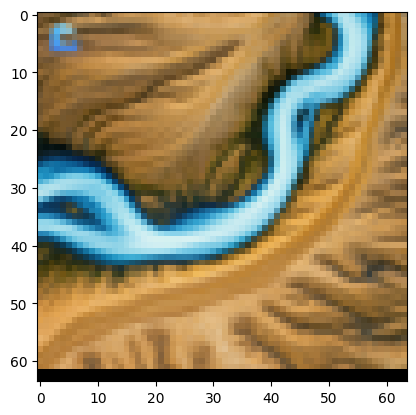

In [ ]:
plt.imshow(river[0]/255.)

In [ ]:
river_pred = model.predict(river)
river_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[1.30871435e-14, 1.19178051e-13, 1.26736708e-07, 4.40819629e-14,
        1.85771895e-17, 4.67632829e-14, 1.43545800e-16, 1.93803909e-18,
        9.99999881e-01, 2.93640925e-13]], dtype=float32)

In [ ]:
# 1. Get the probabilities and indices for the top 3
top_3_values, top_3_indices = tf.math.top_k(river_pred[0], k=3)

# 2. Convert to numpy for easy printing/looping
probs = top_3_values.numpy()
indices = top_3_indices.numpy()

# 3. Print the results
print("Top 3 Predictions:")
for i in range(3):
    class_name = labels[indices[i]]
    confidence = probs[i] * 100
    print(f"{i+1}: {class_name} ({confidence:.2f}%)")

Top 3 Predictions:
1: River (100.00%)
2: HerbaceousVegetation (0.00%)
3: SeaLake (0.00%)


In [ ]:
urban = load_and_prep_image('urban_test.png')
urban

<tf.Tensor: shape=(1, 64, 64, 3), dtype=float32, numpy=
array([[[[17.9881   , 22.07693  , 20.147081 ],
         [19.554108 , 24.607605 , 23.237307 ],
         [19.520655 , 25.572247 , 24.753958 ],
         ...,
         [22.992533 , 29.538242 , 25.835001 ],
         [ 0.       ,  0.       ,  0.       ],
         [ 0.       ,  0.       ,  0.       ]],

        [[18.31367  , 25.967505 , 26.164682 ],
         [11.988187 , 23.150375 , 25.368633 ],
         [ 9.253218 , 21.84609  , 24.760252 ],
         ...,
         [57.98482  , 63.016533 , 58.801647 ],
         [ 0.       ,  0.       ,  0.       ],
         [ 0.       ,  0.       ,  0.       ]],

        [[ 8.46253  , 21.341915 , 24.826403 ],
         [ 7.1127715, 20.541748 , 24.249315 ],
         [ 7.2347383, 20.745453 , 24.288471 ],
         ...,
         [84.413994 , 87.26655  , 80.3721   ],
         [ 0.       ,  0.       ,  0.       ],
         [ 0.       ,  0.       ,  0.       ]],

        ...,

        [[ 6.1232333, 20.244852 , 23

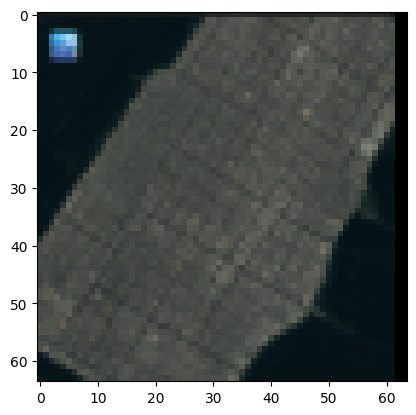

In [ ]:
plt.imshow(urban[0]/255.)

In [ ]:
urban_pred = model.predict(urban)
urban_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[9.9954325e-01, 7.8924502e-09, 4.4556722e-07, 2.6026107e-06,
        1.0856147e-08, 2.1618912e-06, 2.7001452e-05, 3.2140809e-04,
        1.0280698e-04, 1.9385769e-07]], dtype=float32)

In [ ]:
def get_top_3_predictions(prediction):
  # 1. Get the probabilities and indices for the top 3
  top_3_values, top_3_indices = tf.math.top_k(prediction[0], k=3)

  # 2. Convert to numpy for easy printing/looping
  probs = top_3_values.numpy()
  indices = top_3_indices.numpy()

  # 3. Print the results
  print("Top 3 Predictions:")
  for i in range(3):
      class_name = labels[indices[i]]
      confidence = probs[i] * 100
      print(f"{i+1}: {class_name} ({confidence:.2f}%)")

In [ ]:
get_top_3_predictions(urban_pred)

Top 3 Predictions:
1: AnnualCrop (99.95%)
2: Residential (0.03%)
3: River (0.01%)


In [ ]:
agriculture = load_and_prep_image('agriculture.png')
agriculture

<tf.Tensor: shape=(1, 64, 64, 3), dtype=float32, numpy=
array([[[[ 45.559746,  47.889202,  28.956167],
         [ 63.338806,  65.74996 ,  31.359104],
         [ 58.09348 ,  66.83413 ,  30.333027],
         ...,
         [ 51.014633,  50.787598,  42.59592 ],
         [  0.      ,   0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      ]],

        [[ 90.639404,  85.58262 ,  30.855112],
         [ 90.50161 ,  86.808105,  28.941547],
         [ 78.82594 ,  83.13012 ,  26.91163 ],
         ...,
         [134.30965 ,  94.67433 ,  44.62962 ],
         [  0.      ,   0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      ]],

        [[ 67.56695 ,  79.07794 ,  26.52987 ],
         [ 53.823345,  72.16071 ,  21.585423],
         [ 44.873154,  68.54536 ,  19.616215],
         ...,
         [143.83827 ,  98.29824 ,  40.18047 ],
         [  0.      ,   0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      ]],

        ...,

        [[ 69.95798 ,  85.17482 ,  2

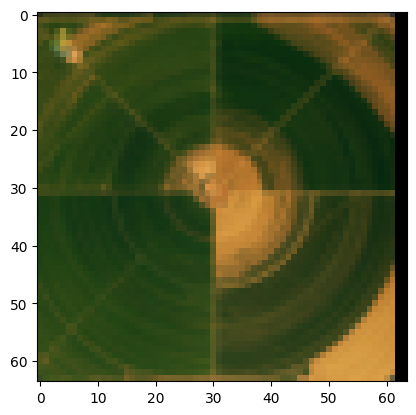

In [ ]:
plt.imshow(agriculture[0]/255.)

In [ ]:
agriculture_pred = model.predict(agriculture)
agriculture_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[1.6047654e-01, 9.5439813e-05, 2.8433159e-04, 3.0011886e-05,
        1.0248130e-03, 1.1732883e-04, 1.0939965e-02, 1.3865864e-05,
        8.2695276e-01, 6.4941261e-05]], dtype=float32)

In [ ]:
get_top_3_predictions(agriculture_pred)

Top 3 Predictions:
1: River (82.70%)
2: AnnualCrop (16.05%)
3: PermanentCrop (1.09%)


Image shape: (64, 64, 3)


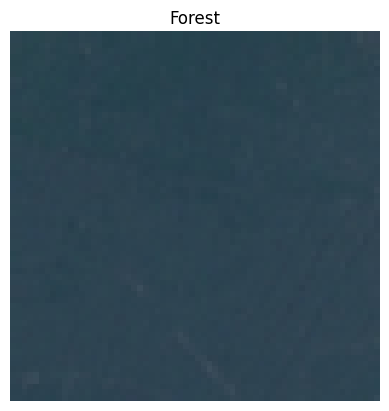

In [ ]:
test_image, filename = view_random_image('/content/drive/MyDrive/EuroSAT/test/',
                                          target_class='Forest')

In [ ]:
test_image = load_and_prep_image(filename)
pred = model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
get_top_3_predictions(pred)

Top 3 Predictions:
1: Forest (100.00%)
2: HerbaceousVegetation (0.00%)
3: Pasture (0.00%)


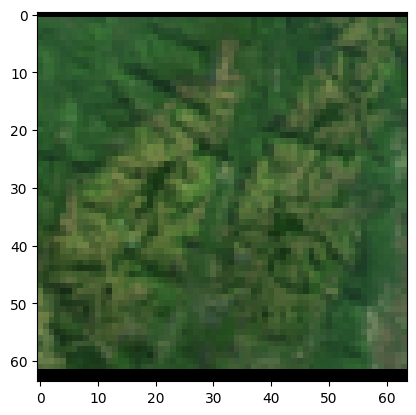

In [ ]:
forest = load_and_prep_image('forest.png')
plt.imshow(forest[0]/255.)

In [ ]:
get_top_3_predictions(model.predict(forest))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Top 3 Predictions:
1: HerbaceousVegetation (99.59%)
2: Forest (0.41%)
3: PermanentCrop (0.00%)


## Confusion Matrix

How well is the test data distributed across classes?

In [ ]:
# walking through the test set
walk('/content/drive/MyDrive/EuroSAT/test')

There are 10 directories and 0 images in'/content/drive/MyDrive/EuroSAT/test'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/AnnualCrop'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/Forest'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/HerbaceousVegetation'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/Highway'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/Industrial'
There are 0 directories and 200 images in'/content/drive/MyDrive/EuroSAT/test/Pasture'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/PermanentCrop'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/Residential'
There are 0 directories and 250 images in'/content/drive/MyDrive/EuroSAT/test/River'
There are 0 directories and 300 images in'/content/drive/MyDrive/EuroSAT/test/SeaLake'
Total images: 2700.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

# function to make a confusion matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 15), text_size=10):
  """
  Makes a confusion matrix comparison between y_true labels (original) and
  y_pred labels (predicted)

  Parameters:
    y_true: array-like of shape (n_samples,)
  	Ground truth (correct) target values.
  	y_pred: array-like of shape (n_samples,)
  	Estimated targets as returned by a classifier
  """
  # Create the confusion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
  n_classes = cm.shape[0]

  # Prettify the plot
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm_norm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  # set labels (EuroSAT Classes)
  labels = classes if classes else np.arange(cm.shape[0])

  ax.set(title='S.I.L.C. - EuroSAT Confusion Matrix',
         xlabel="Predicted Label",
         ylabel="True Label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  ax.xaxis.set_label_position('bottom')
  ax.xaxis.tick_bottom()

  # rotate labels if they overlap
  plt.xticks(rotation=45)

  # setting our threshold for text readability
  threshold = (cm.max() + cm.min()) / 2.

  # plotting the test (count + percentage) on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment='center',
             color='white' if cm[i, j] > threshold else 'black',
             size=text_size)

  plt.show()

In [ ]:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
 'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
 'River', 'SeaLake'] == labels

True

In [ ]:
# loading our model
model = load_model('best_efficientnet_fine_10_layers_model_full_train.keras')

In [ ]:
y_true = np.concatenate([y for x, y in test_data], axis=0)

y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"True labels shape: {y_true.shape}")
print(f"Predicted labels shape: {y_pred.shape}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step
True labels shape: (2700, 10)
Predicted labels shape: (2700,)


In [ ]:
y_pred

array([0, 0, 0, ..., 2, 9, 9])

In [ ]:
# flattening the true labels array
y_true_indices = np.argmax(y_true, axis=1)

print(f"New y_true shape: {y_true_indices.shape}")
print(f"y_pred shape: {y_pred.shape}")

New y_true shape: (2700,)
y_pred shape: (2700,)


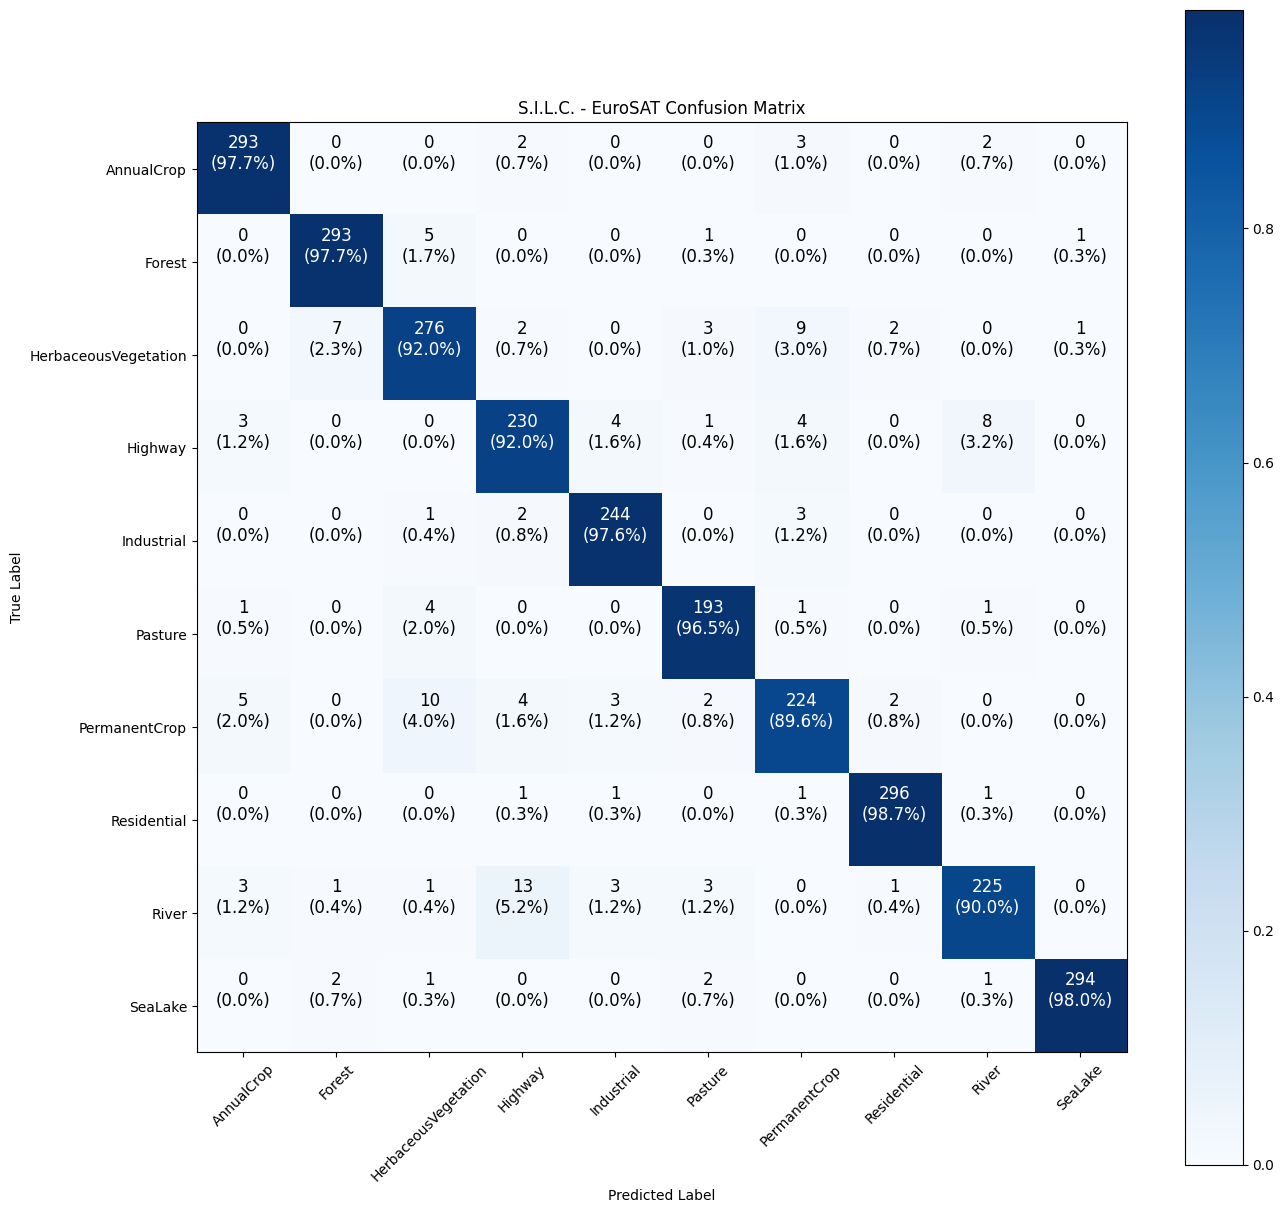

In [ ]:
# now lets call my function
make_confusion_matrix(y_true=y_true_indices,
                      y_pred=y_pred,
                      classes=labels,
                      text_size=12)